# Chroma Embeddings Visualization

Load recipe embeddings from Chroma and visualize them with a simple PCA projection.

In [1]:
import os
from pathlib import Path

import rootutils

In [2]:
rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

ROOT_DIR = Path(os.environ.get("PROJECT_ROOT", Path.cwd()))

In [6]:
PERSIST_DIR = ROOT_DIR / "data" / "chroma"
COLLECTION_NAME = "recipe_embeddings"
LIMIT = None  # set to an int to subsample

In [ ]:
import chromadb

temp_client = chromadb.PersistentClient(path=str(PERSIST_DIR))
collections = temp_client.list_collections()
print(f"Available collections in {PERSIST_DIR}:")
for col in collections:
    print(f"  - {col.name} (count: {col.count()})")


Available collections in /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma:
  - recipe_embeddings (count: 150)


In [8]:
import chromadb
import numpy as np


client = chromadb.PersistentClient(path=str(PERSIST_DIR))

collection = client.get_collection(COLLECTION_NAME)

get_kwargs = {"include": ["embeddings", "metadatas", "documents"]}
if LIMIT is not None:
    get_kwargs["limit"] = LIMIT

payload = collection.get(**get_kwargs)
embeddings = np.array(payload["embeddings"], dtype=np.float32)
metadatas = payload.get("metadatas") or []
documents = payload.get("documents") or []
ids = payload.get("ids") or []

print(f"Loaded {embeddings.shape[0]} vectors, dim={embeddings.shape[1]}")
print("Sample ids:", ids[:5])

Loaded 150 vectors, dim=64
Sample ids: ['recipe_aeropress_027', 'recipe_aeropress_decaf_140', 'recipe_aeropress_large_067', 'recipe_aeropress_with_cinnamon_115', 'recipe_affogato_029']


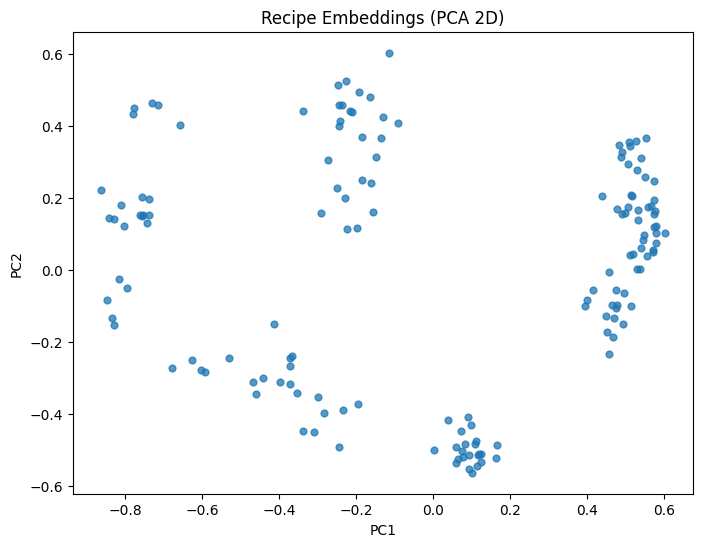

In [9]:
import matplotlib.pyplot as plt


def pca_2d(x: np.ndarray) -> np.ndarray:
    x_centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
    return x_centered @ vt[:2].T


points = pca_2d(embeddings)
names = [meta.get("name", "") if isinstance(meta, dict) else "" for meta in metadatas]

plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], s=24, alpha=0.75)

if len(names) <= 30:
    for idx, name in enumerate(names):
        if name:
            plt.text(points[idx, 0], points[idx, 1], name, fontsize=8, alpha=0.8)

plt.title("Recipe Embeddings (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()